### Notebook modelo de árbol de decisión y vecinos cercanos

En esta sesión nos concentraremos en la aplicación práctica de ambos modelos usando un pequeño conjunto de datos de habitabilidad de exoplanetas.

**Objetivos:**
- entrenar un **árbol de decisión** y un clasificador **kNN** con `scikit-learn`,
- interpretar predicciones y calcular `accuracy`,
- comparar ambos métodos en un mismo problema,
- entender por qué **kNN requiere escalamiento** de variables y los árboles no necesariamente.


(Adaptado de  Viviana Acquaviva (2023))



## Decision Trees

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html


https://www.kaggle.com/code/willkoehrsen/visualize-a-decision-tree-w-python-scikit-learn

In [126]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd 
import seaborn as sns

In [127]:
font = {'size'   : 10}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=10) 
matplotlib.rc('ytick', labelsize=10) 
matplotlib.rcParams['figure.dpi'] = 300

In [128]:
#Paquetes para visualización

from io import StringIO
from IPython.display import Image  
import pydotplus

from sklearn.tree import export_graphviz 

### Subconjunto de base de datos de Habitabilidad de planetas https://phl.upr.edu/projects/habitable-exoplanets-catalog

In [129]:
LearningSet = pd.read_csv('HPLearningSet.csv', index_col=0)

**Variables:**
- `S_MASS`: masa estelar ($M_\odot$)
- `P_PERIOD`: período orbital (días)
- `P_DISTANCE`: distancia planeta–estrella (AU)
- `P_HABITABLE`: clase objetivo (0 = no habitable, 1 = habitable)


In [130]:
LearningSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [131]:
LearningSet.shape[0], LearningSet.describe(), LearningSet.info(), LearningSet.columns

<class 'pandas.core.frame.DataFrame'>
Index: 18 entries, 0 to 17
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   P_NAME       18 non-null     object 
 1   S_MASS       18 non-null     float64
 2   P_PERIOD     18 non-null     float64
 3   P_DISTANCE   18 non-null     float64
 4   P_HABITABLE  18 non-null     int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 864.0+ bytes


(18,
           S_MASS     P_PERIOD  P_DISTANCE  P_HABITABLE
 count  18.000000    18.000000   18.000000    18.000000
 mean    0.636667    95.878659    0.274841     0.444444
 std     0.327755   255.167845    0.496635     0.511310
 min     0.090000     3.601472    0.025200     0.000000
 25%     0.440000     6.926365    0.056170     0.000000
 50%     0.615000    14.716330    0.112745     0.000000
 75%     0.857500    55.993541    0.252982     1.000000
 max     1.190000  1103.000000    2.180981     1.000000,
 None,
 Index(['P_NAME', 'S_MASS', 'P_PERIOD', 'P_DISTANCE', 'P_HABITABLE'], dtype='object'))

### Haga una revisión rápida del set de datos
- Encuentre el tamaño del dataset, y las categorías de la variable `P_HABITABLE` y los ejemplos en cada categoría.
- También visualice la relación entre la masa, el periodo y la habitabilidad del planeta. Grafique el periodo en escala log

In [132]:
print("Tamaño del dataset:", LearningSet.shape)
print("\nConteo por categoría:")
print(LearningSet['P_HABITABLE'].value_counts())

Tamaño del dataset: (18, 5)

Conteo por categoría:
P_HABITABLE
0    10
1     8
Name: count, dtype: int64


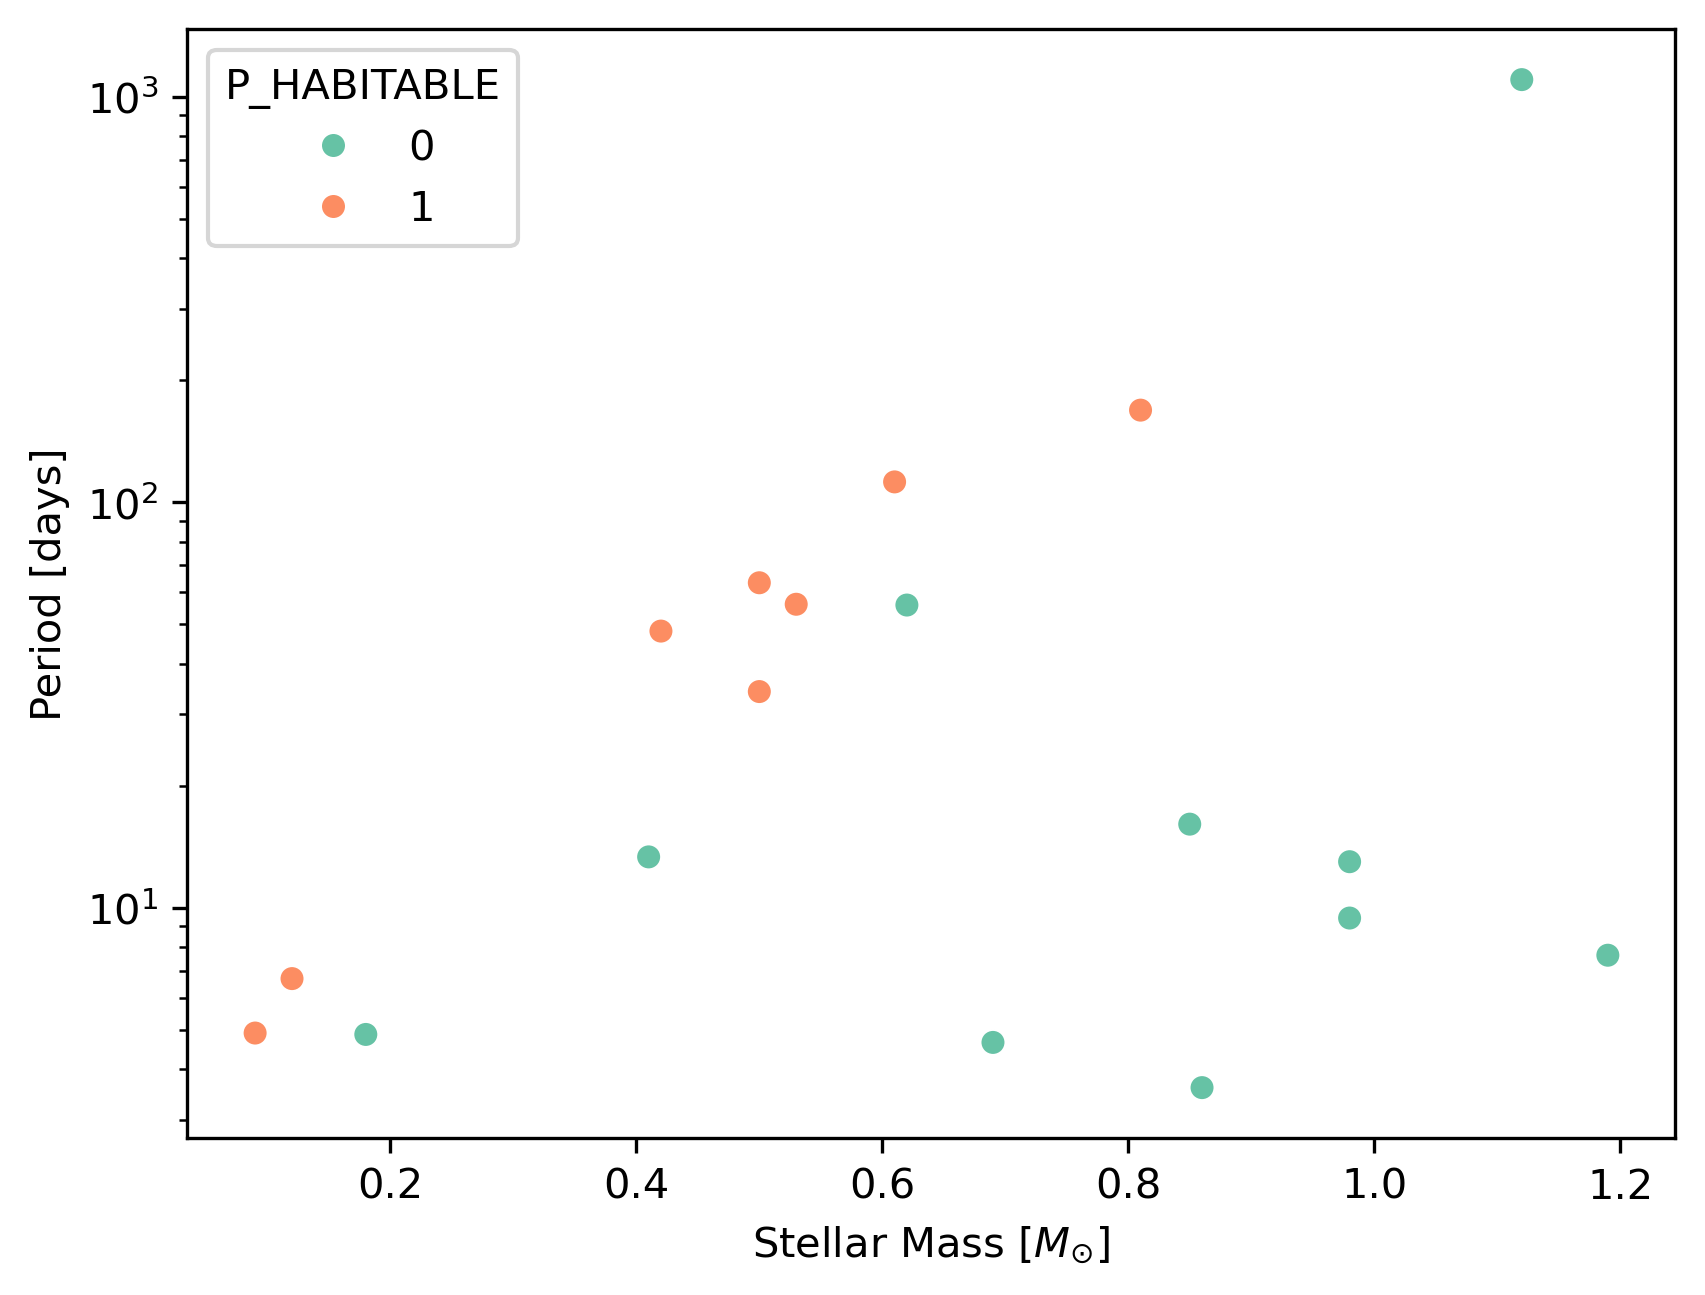

In [133]:
sns.scatterplot(data=LearningSet, x="S_MASS", y="P_PERIOD", hue="P_HABITABLE", palette="Set2")
plt.yscale('log')
plt.xlabel(r'Stellar Mass [$M_{\odot}$]')
plt.ylabel("Period [days]")
plt.show()

**Antes de entrenar un modelo, te parece que las clases se separan fácilmente o no? Explique**




A simple vista parece que sí; los planetas habitables están separados de los no habitables por una franja diagonal, por lo que sería idóneo desarrollar un modelo que pueda hacer esta separaciónA simple vista parece que sí; los planetas habitables están separados de los no habitables por una franja diagonal, por lo que sería idóneo desarrollar un modelo que pueda hacer esta separaciónA simple vista puede ser que sí, los planetas habitables estan separados de los no habitables por una franja diagonal por lo seria idoneo desarrollar un modelo que pueda hacer esta separación

### Elijamos el set de entrenamiento y prueba

Para definir los sets de etrenamiento y prueba, haremos una división *manual*

Definimos que las primeras 13 filas del dataframe será el conjunto de entrenamiento y los últimos 5, el conjunto de prueba

> En un problema real, usualmente preferimos una división aleatoria o validación cruzada.


Usaremos .iloc para acceder a los índices del dataframe

In [134]:
LearningSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [135]:
TrainSet =  LearningSet.iloc[:13,:]  
TestSet = LearningSet.iloc[13:,:]

In [136]:
TrainSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [137]:
TestSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
13,HD 104067 b,0.62,55.80600,0.260000,0
14,GJ 4276 b,0.41,13.35200,0.087613,0
15,Kepler-296 f,0.50,63.33627,0.268885,1
16,Kepler-63 b,0.98,9.43415,0.088100,0
17,GJ 3293 d,0.42,48.13450,0.195336,1


También necesitamos definir para cada conjunto las características (features) y los objetivos (targets)

In [138]:
Xtrain = TrainSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features conjunto de entrenamiento
Xtest = TestSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features  conjunto de entrenamiento

In [139]:
Xtrain.columns

Index(['S_MASS', 'P_PERIOD', 'P_DISTANCE'], dtype='object')

In [140]:
ytrain = TrainSet.P_HABITABLE #target conjunto prueba
ytest = TestSet.P_HABITABLE  #target conjunto prueba

In [141]:
Xtrain,Xtest

(    S_MASS     P_PERIOD  P_DISTANCE
 0     0.86     3.601472    0.043718
 1     0.85    16.080661    0.118082
 2     1.19     7.638460    0.080420
 3     0.61   112.305300    0.409327
 4     0.98    12.992073    0.107408
 5     0.09     4.910000    0.025200
 6     0.69     4.655411    0.048086
 7     0.12     6.689000    0.035000
 8     1.12  1103.000000    2.180981
 9     0.81   168.811170    0.557107
 10    0.50    34.142110    0.178202
 11    0.53    56.056054    0.231926
 12    0.18     4.871229    0.031746,
     S_MASS  P_PERIOD  P_DISTANCE
 13    0.62  55.80600    0.260000
 14    0.41  13.35200    0.087613
 15    0.50  63.33627    0.268885
 16    0.98   9.43415    0.088100
 17    0.42  48.13450    0.195336)

In [142]:
ytrain,ytest

(0     0
 1     0
 2     0
 3     1
 4     0
 5     1
 6     0
 7     1
 8     0
 9     1
 10    1
 11    1
 12    0
 Name: P_HABITABLE, dtype: int64,
 13    0
 14    0
 15    1
 16    0
 17    1
 Name: P_HABITABLE, dtype: int64)

### Entrenamos el modelo
Nota: En los árboles de decisión de scikit-learn, las características (o variables) se reorganizan aleatoriamente cada vez que se realiza una división para decidir cómo separar los datos. Esto significa que, incluso si se usa el mismo conjunto de datos de entrenamiento, la mejor forma de dividir los datos puede cambiar entre diferentes ejecuciones del modelo. Esta variación ocurre cuando varias divisiones posibles ofrecen la misma mejora en el criterio de evaluación (por ejemplo, reducir la impureza del nodo). En estos casos, el algoritmo puede elegir diferentes divisiones como "mejores" en diferentes ejecuciones debido al orden aleatorio en que se evalúan las características.

Para asegurar que los resultados del entrenamiento sean consistentes y reproducibles (es decir, que se obtenga el mismo árbol de decisión cada vez que se entrene con los mismos datos), es necesario fijar el parámetro random_state. Esto establece una semilla para el generador de números aleatorios utilizado por el algoritmo, garantizando que la permutación de las características sea la misma en cada ejecución y, por lo tanto, el resultado del modelo también sea el mismo.

In [143]:
from sklearn.tree import DecisionTreeClassifier #modelo de árbol de decisión

In [144]:
model = DecisionTreeClassifier(random_state=3) #Inicializamos el modelo con sus parámetros
model.fit(Xtrain, ytrain) #En una línea, construimos el modelo

DecisionTreeClassifier(random_state=3)

### Podemos visualizar el árbol (visualización "pro")

debe instalar la libreria [`pydotplus`](https://pypi.org/project/pydotplus/)  y [`graphviz`](https://pypi.org/project/graphviz/) 

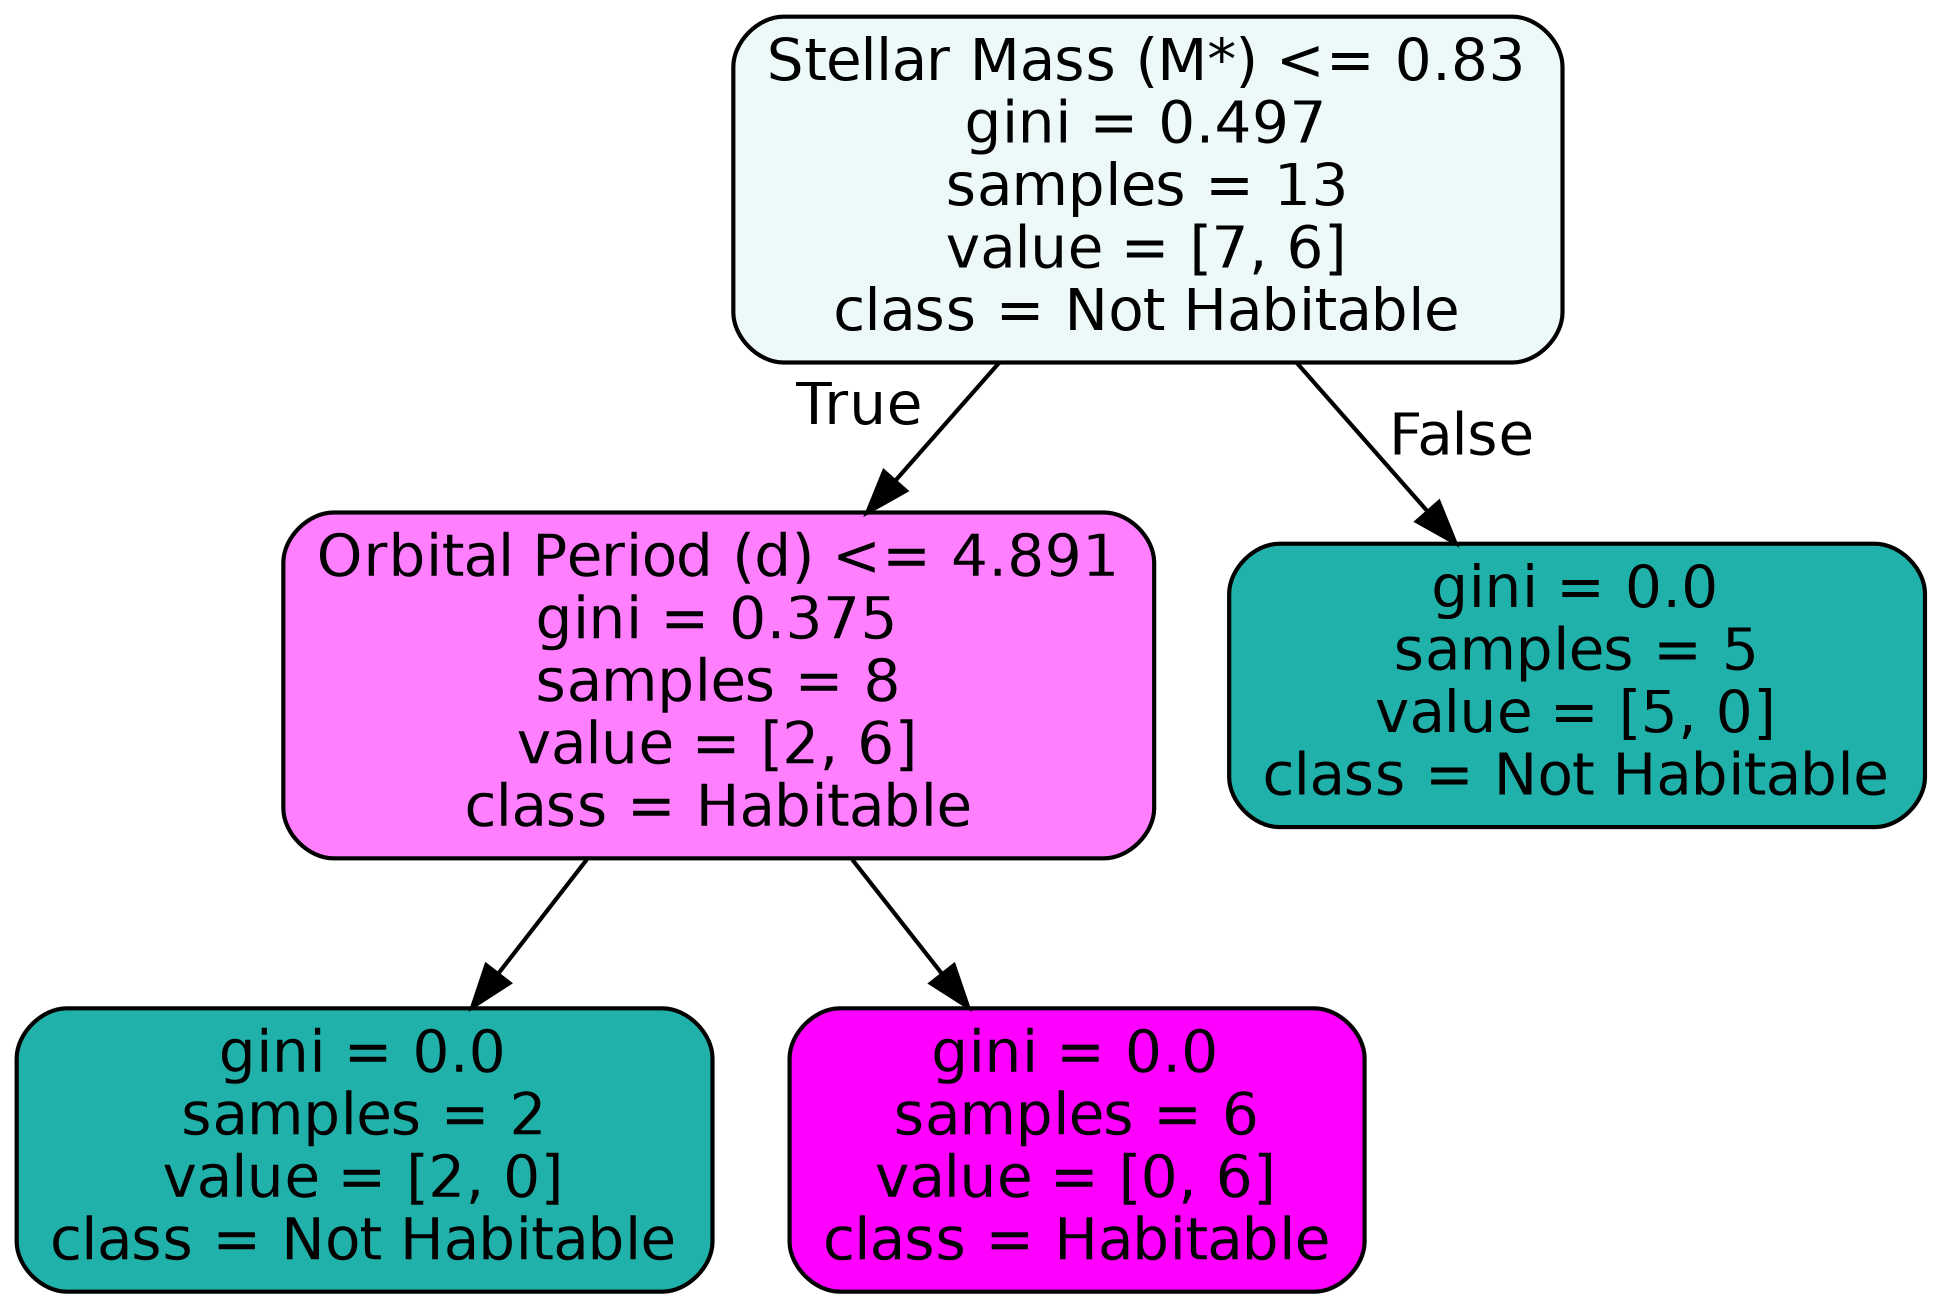

In [145]:
dot_data = StringIO()
export_graphviz(
            model,
            out_file =  dot_data,
            feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
            class_names = ['Not Habitable','Habitable'],
            filled = True,
            rounded = True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))  
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label():
        values = [int(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [255 * v / sum(values) for v in values]
        
        values = [int(255 * v / sum(values)) for v in values]
            
        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha) #turn into hexadecimal
            color = '#20 B2 AA'+str(alpha)
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#FF 00 FF'+str(alpha)
        node.set_fillcolor(color)

graph.set_dpi('300')

Image(graph.create_png())

#Image(graph.write_png('Graph.png'))

### Visualización de sklearn

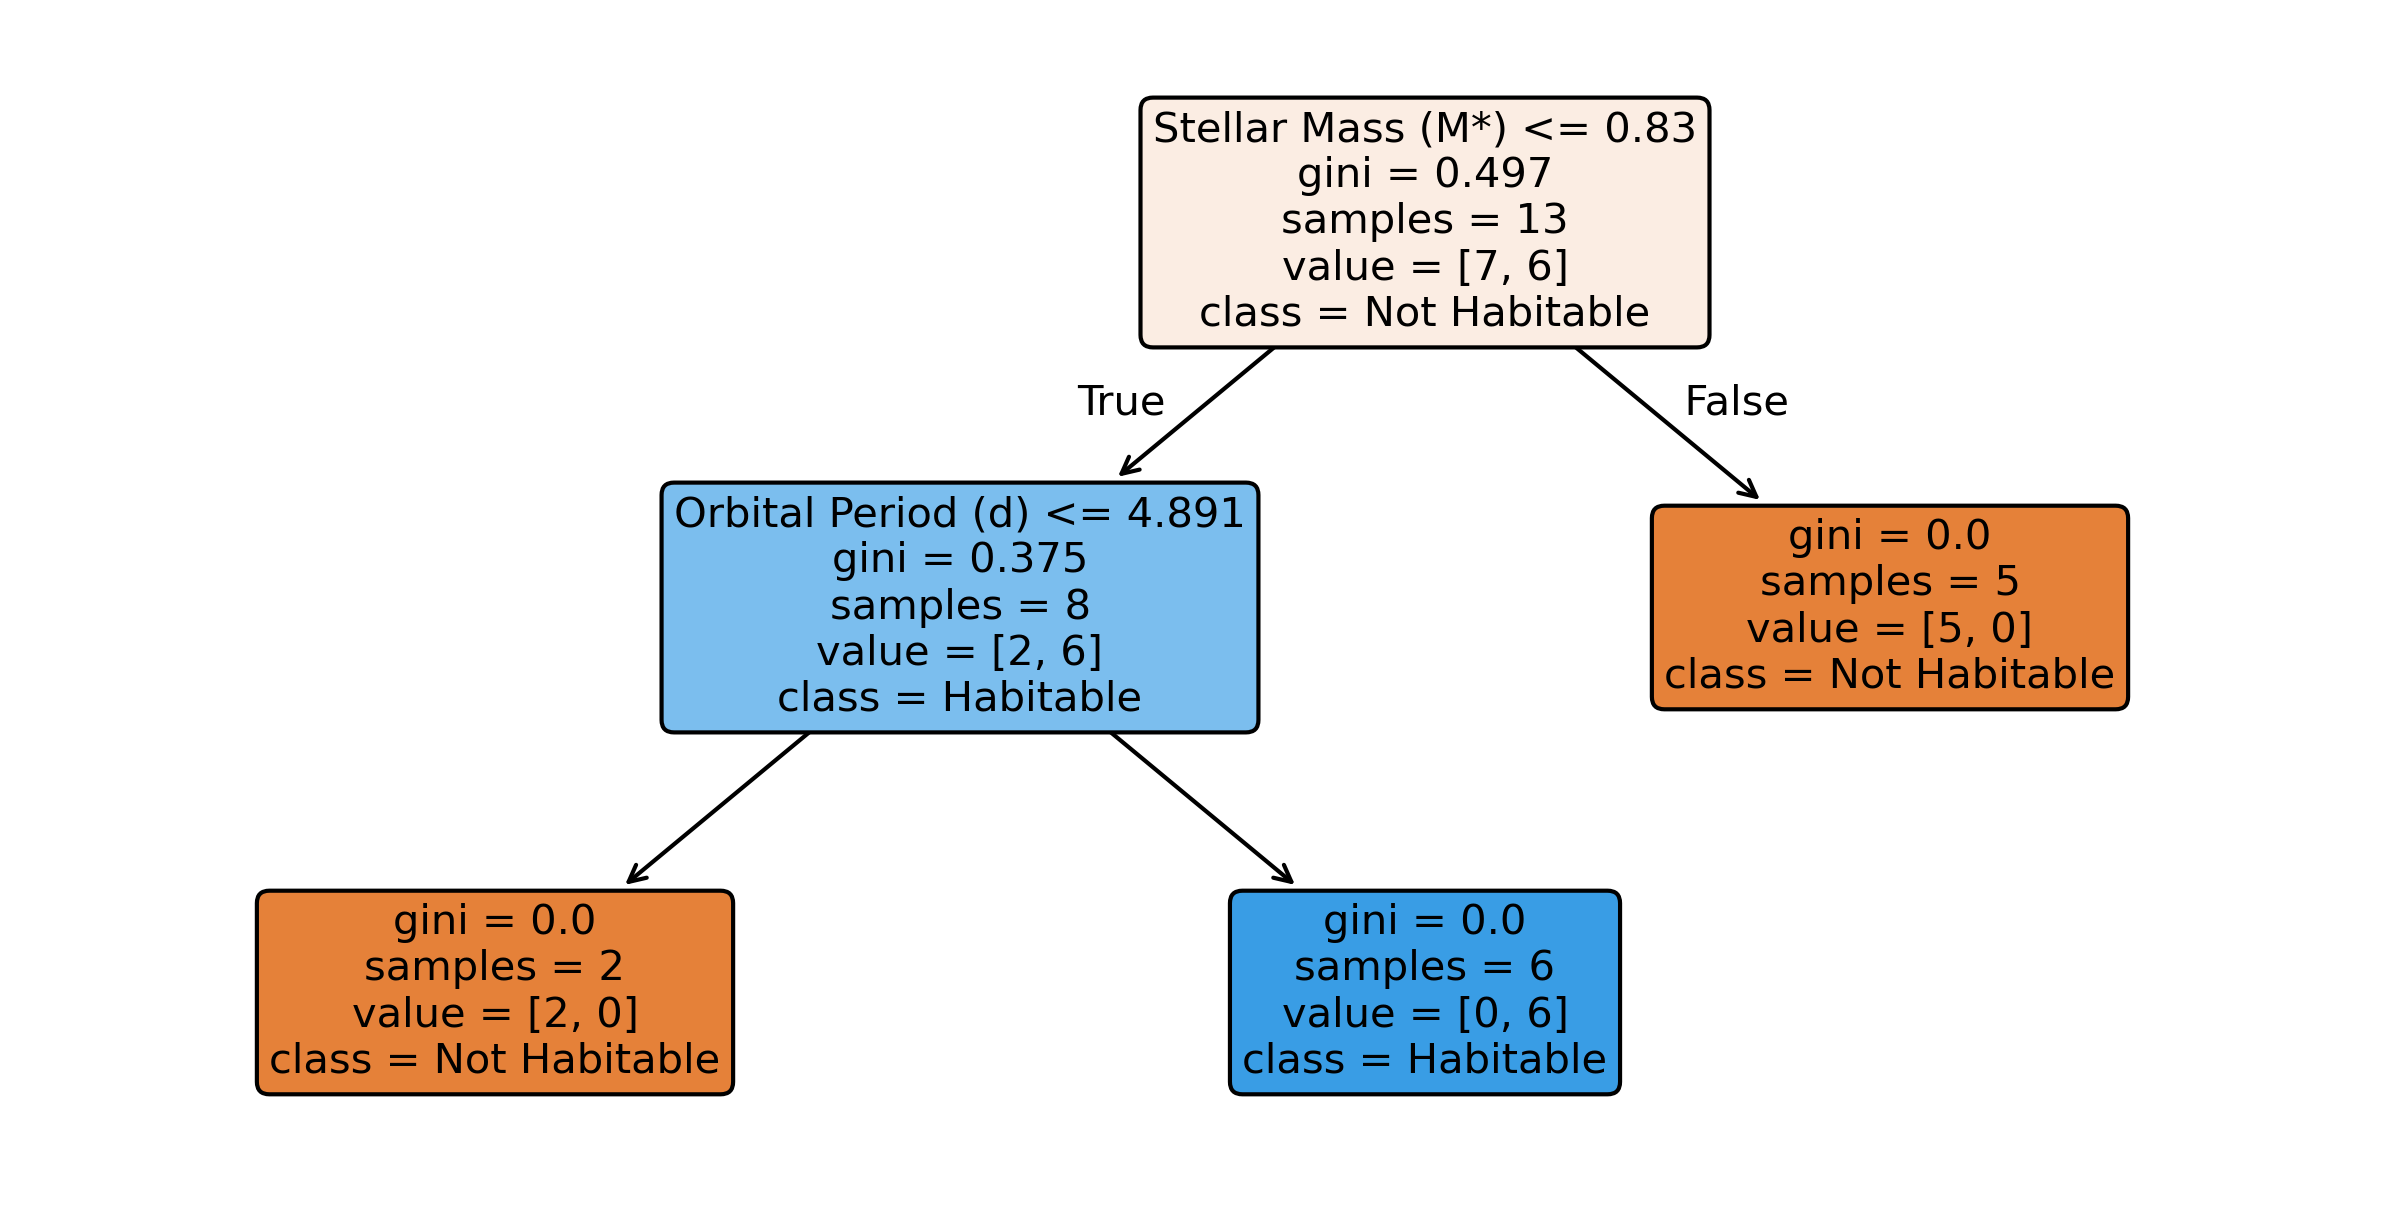

In [146]:
from sklearn import tree

plt.figure(figsize=(10,5))  # puede cambiar de acuerdo al tamaño del árbol
tree.plot_tree(model,
               feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
               class_names = ['Not Habitable','Habitable'],
               filled=True,
               rounded=True,
               fontsize=10)

plt.show()

### También podemos visualizar las decisiones del clasificador. El color de sombreado predice la etiqueta, y el color de los puntos marca la etiqueta real:

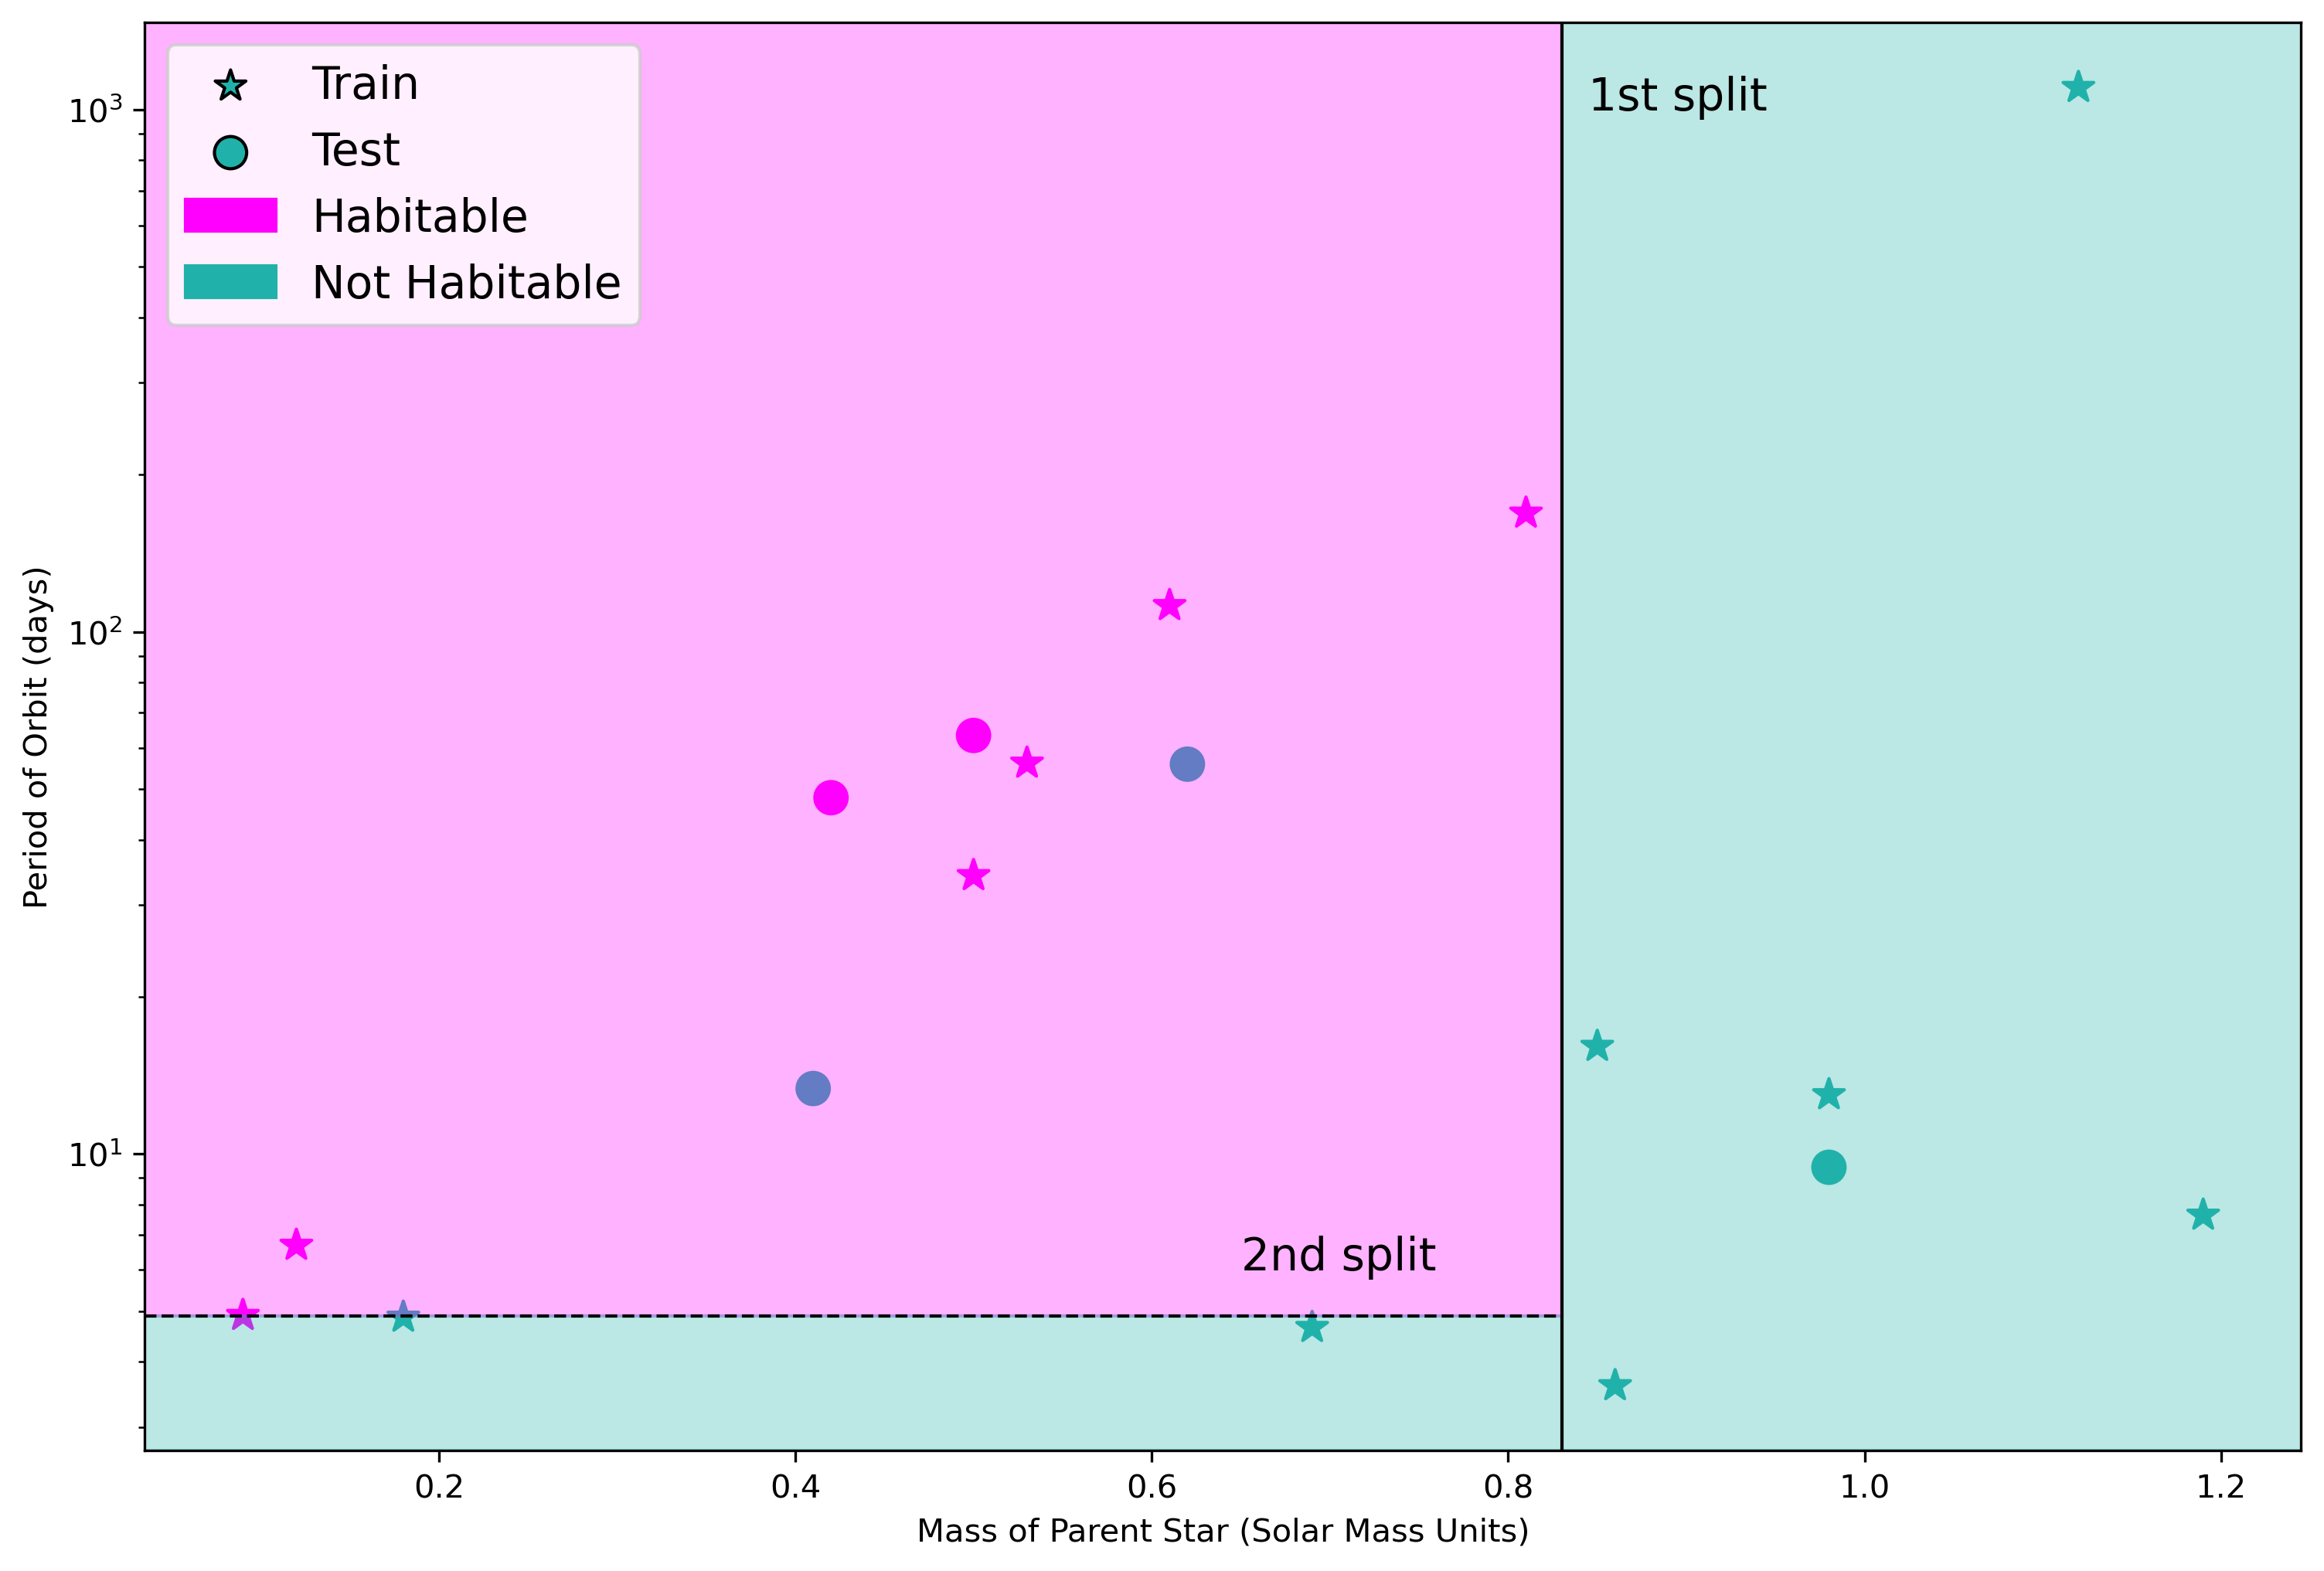

In [147]:
plt.figure(figsize=(12,8))

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

#puntos de entrenamiento y prueba

plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',\
            c = TrainSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Train')

plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',\
            c = TestSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Test')

plt.yscale('log')

plt.xlabel('Mass of Parent Star (Solar Mass Units)')

plt.ylabel('Period of Orbit (days)');

#splits del gráfico

plt.axvline(x=0.83, linewidth =1, ls = '-', label = '1st split', c='k')

plt.axhline(y=4.891, xmin = 0, xmax = 0.655, linewidth =1, ls = '--', label = '2nd split',c='k')

plt.text(0.845, 10**3, '1st split', fontsize=14)
         
plt.text(0.65, 6, '2nd split', fontsize=14)

#leyenda

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')

magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()

predhab = mpatches.Rectangle((0,4.891),0.83,ax.get_ylim()[1], 
                        fill = True,
                        color = '#FF00FF',
                        alpha = 0.3)

prednothab1 = mpatches.Rectangle((0.83,ax.get_ylim()[0]),ax.get_xlim()[1],ax.get_ylim()[1], 
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

prednothab2 = mpatches.Rectangle((0,ax.get_ylim()[0]),0.83,4.891-ax.get_ylim()[0], 
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')

plt.gca().add_patch(predhab)
plt.gca().add_patch(prednothab1)
plt.gca().add_patch(prednothab2)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14);

### Pregunta 
    
- ¿Cuál es el porcentaje de clasificaciones correctas en el set de entrenamiento?  Y en el set de prueba?

A este porcentaje de clasificaciones correctas lo llamaremos **accuracy**


Para el set de entrenamiento hay un 100% de accuary, el árbol clasificó correctamente los 13 datos utilizados para entrenar, llegando a que sus hojas puras en donde el coeficiente de Gini es 0. Para el set de prueba el resultado fue totalmente distinto para una colección de 5 datos, el modelo acierta 3 datos y se equivoca con los 2 restantes llegando a un 60% de accuary.

### usando la métricas de sklearn, podemos encontrar el accuracy


In [148]:
import sklearn.metrics as metrics

In [149]:
ypred = model.predict(Xtest) #generamos etiquetas de predicción en el set de prueba

In [150]:
ypred

array([1, 1, 1, 0, 1])

Accuracy es una métrica usual para evaluar modelos de clasificación, y hay una función en el módulo `sklearn.metrics`. Tenemos que comparar los resultados de la predicción `ypred` con los valores reales `ytest`

In [151]:
metrics.accuracy_score(ytest, ypred) #test score

0.6

también podemos encontrar el accuracy de los datos de entrenamiento, generando predicciones para los `Xtrain` y comparando con el `ytrain`

In [152]:
metrics.accuracy_score(ytrain, model.predict(Xtrain)) #train score

1.0

### Preguntas de interpretación
1. ¿El árbol clasifica perfectamente el conjunto de entrenamiento?

Si, el árbol pudo clasificar perfectamente el conjunto de entrenamiento ya que todas las hojas tiene un gini de 0.

2. ¿Qué ocurre en el conjunto de prueba?

El modelo cometió algunos errores, logrando solamente un 60% de accuracy, de los 5 acerto 3 y falló 2. Estos dos que fallaron caen en las condiciones dadas para considerarse habitable ($ M \leq 0.83 M_{\odot} $ y $ P \leq 4.891 days$) pero estos se consideraban realmente no habitables, mostrando que realmente el árbol hizo un overfitting debido al bajo porcentaje y también a la poca cantidad de datos.

3. ¿Qué variable aparece en la raíz del árbol?

La variable que aparece en la raíz del árbol es la masa estelar del dataset, la cual hizo una division de mayor o menor que $0.83 M_{\odot}$

4. ¿Te parece que este árbol es simple o ya es relativamente profundo para un dataset tan pequeño?

El modelo tiene una estructura objetivamente simple, con una profundidad de solo 2 splits. Sin embargo, al ser un dataset tan pequeño, esta profundidad fue suficiente para sobreajustar los datos. Cabe destacar que el tamaño final es relativo, ya que la complejidad y profundidad del árbol siempre pueden controlarse ajustando los hiperparámetros antes de entrenarlo.


### Ahora elegiremos un set de entrenamiento distinto. Las 5 primeras filas serán de prueba y el resto será para el entrenamiento

In [153]:
# los primeros 5 de prueba, el resto de entrenamiento
TrainSet2 = LearningSet.iloc[5:,:] 
TestSet2 = LearningSet.iloc[:5,:]

### Repita el proceso anterior

1. Defina los dataframes de características y la serie de categorías para entrenamiento y prueba: `Xtrain2`, `Xtest2`, `ytrain2`, `ytest2`
2. inicialice el modelo de árbol de decisión para clasificación (defina semilla `random_state=3`
3. ajuste el modelo a los datos de entrenamiento
4. visualice el árbol
5. calcule accuracy para entrenamiento y prueba

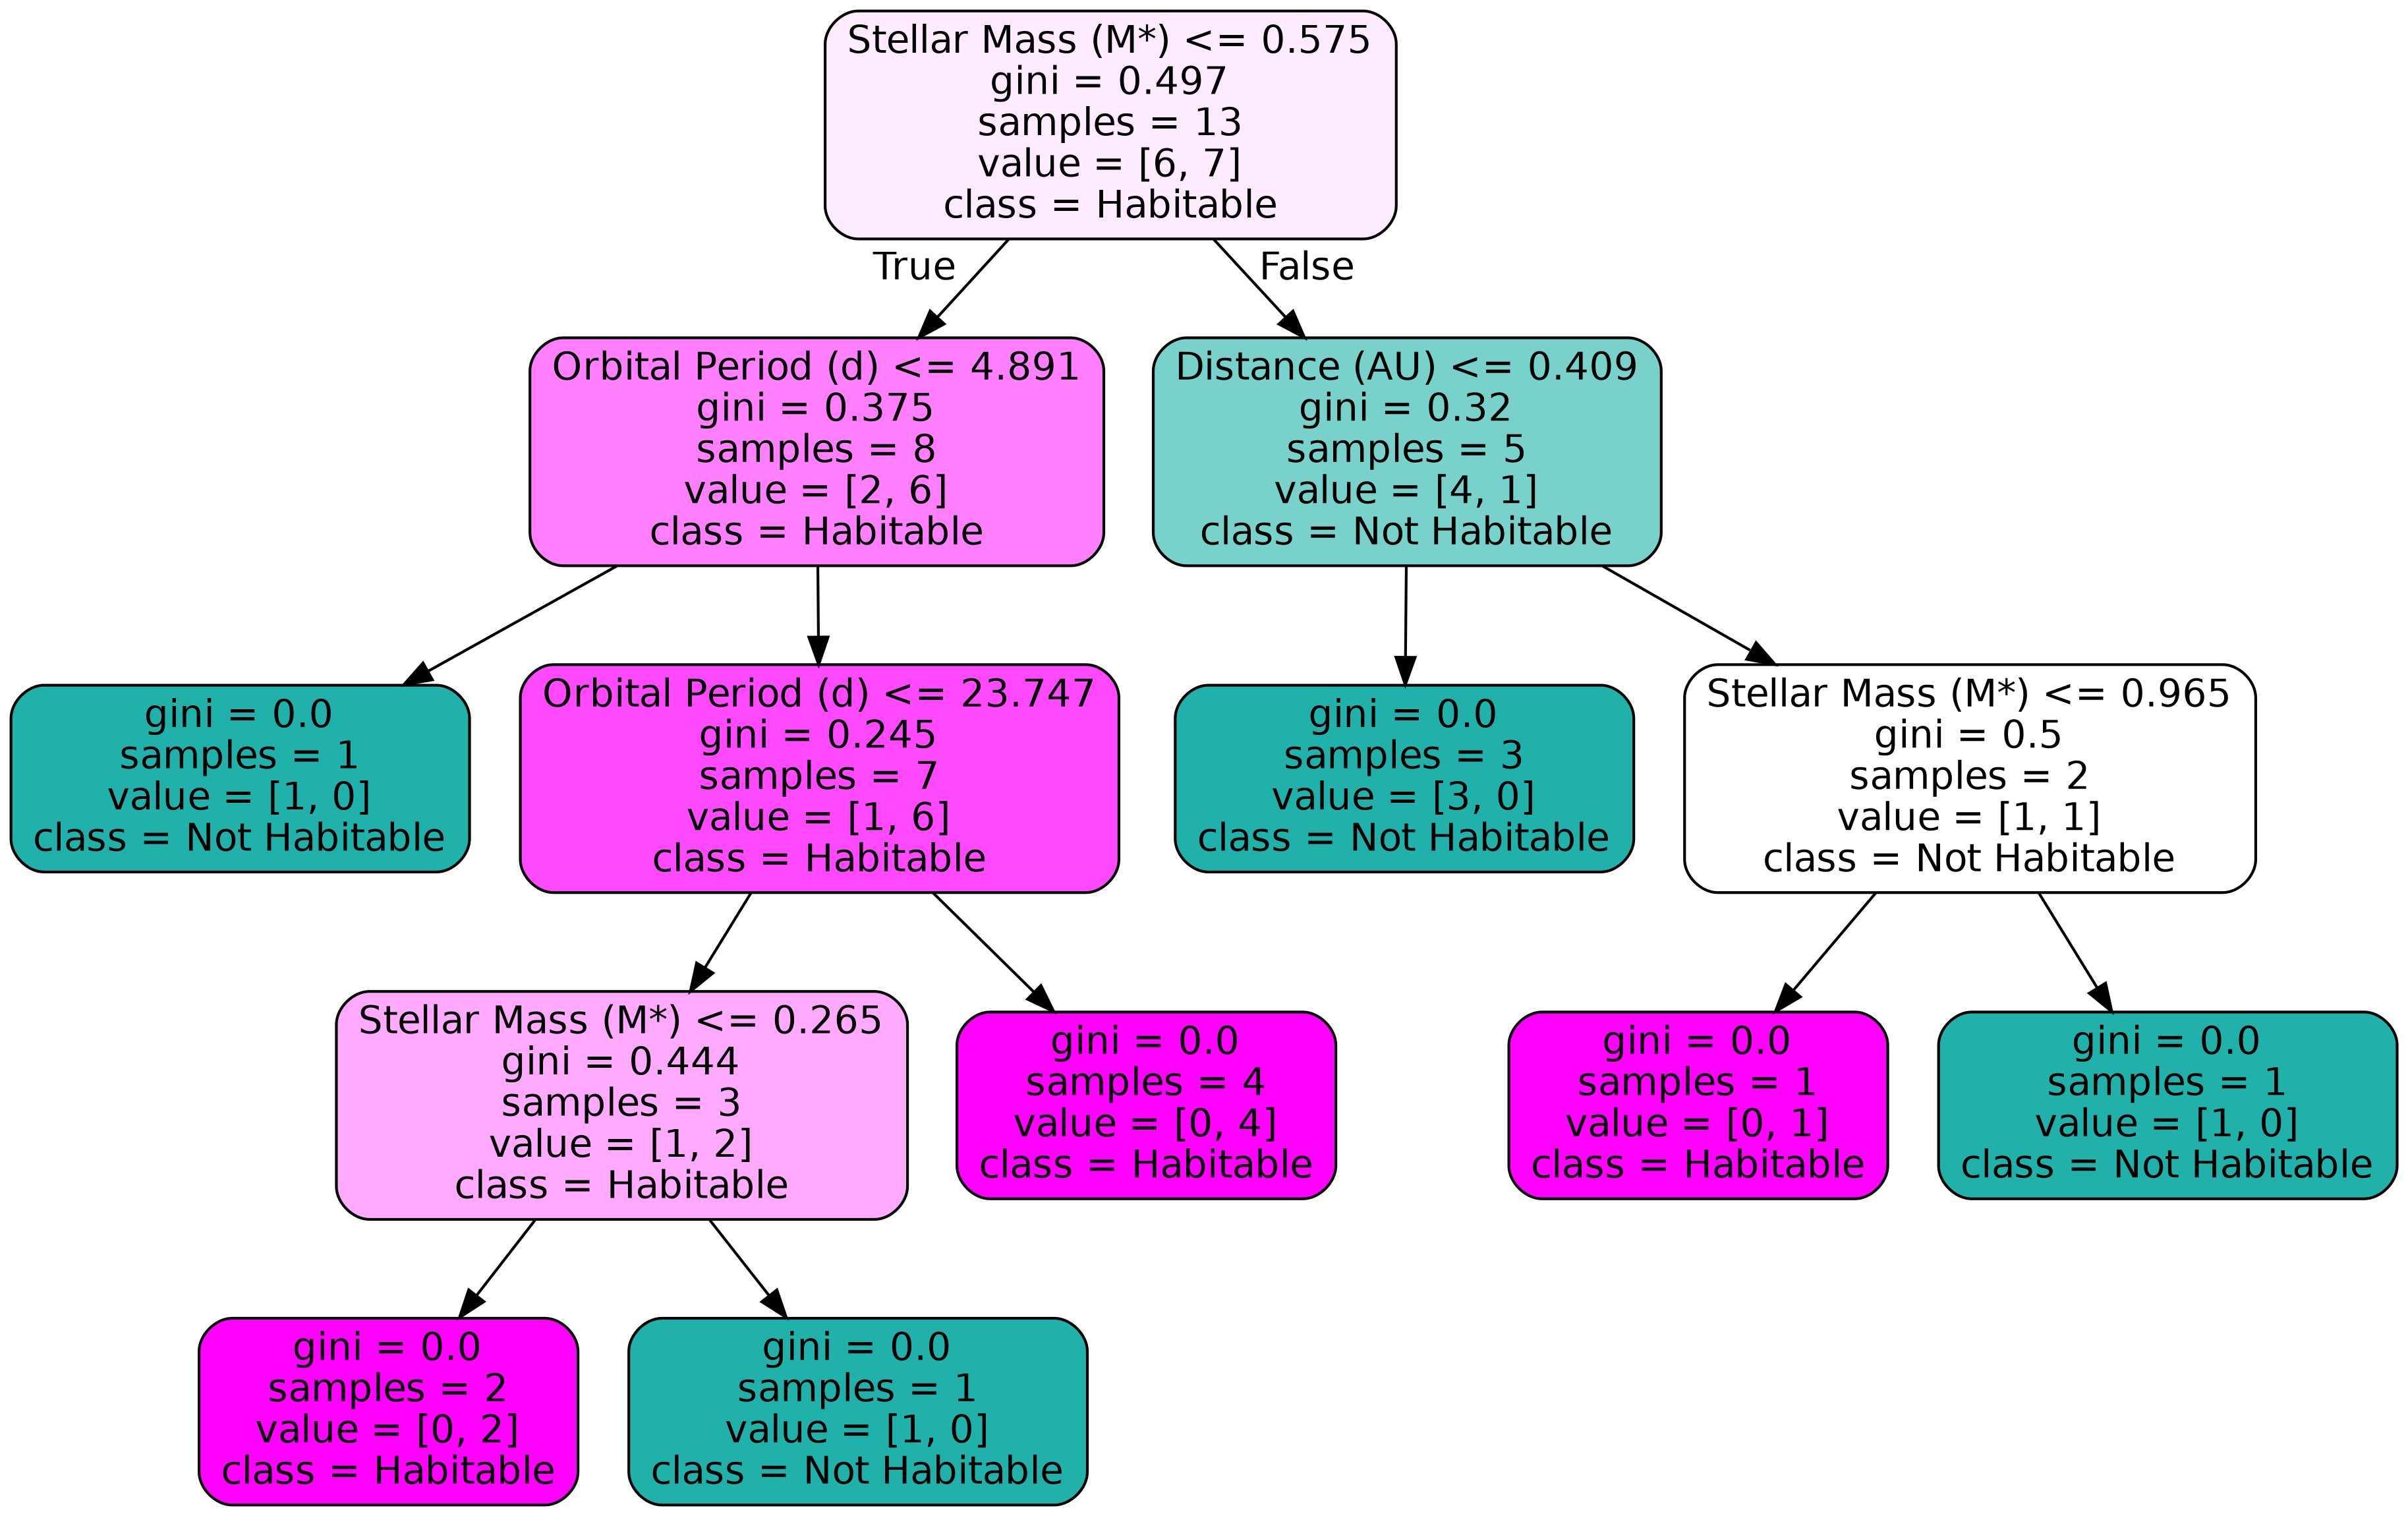

In [154]:
Xtrain2 = TrainSet2.drop(['P_NAME','P_HABITABLE'],axis=1)
Xtest2 = TestSet2.drop(['P_NAME','P_HABITABLE'],axis=1)
ytrain2 = TrainSet2.P_HABITABLE
ytest2 = TestSet2.P_HABITABLE

model2 = DecisionTreeClassifier(random_state=3) #Inicializamos el modelo con sus parámetros
model2.fit(Xtrain2, ytrain2) #En una línea, construimos el modelo

dot_data = StringIO()
export_graphviz(
            model2,
            out_file =  dot_data,
            feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
            class_names = ['Not Habitable','Habitable'],
            filled = True,
            rounded = True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))  
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label():
        values = [int(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [255 * v / sum(values) for v in values]
        
        values = [int(255 * v / sum(values)) for v in values]
            
        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha) #turn into hexadecimal
            color = '#20 B2 AA'+str(alpha)
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#FF 00 FF'+str(alpha)
        node.set_fillcolor(color)

graph.set_dpi('300')

Image(graph.create_png())

#Image(graph.write_png('Graph.png'))



In [155]:
import sklearn.metrics as metrics
ypred2 = model2.predict(Xtest2) #generamos etiquetas de predicción en el set de prueba
metrics.accuracy_score(ytest2, ypred2), metrics.accuracy_score(ytrain2, model2.predict(Xtrain2)) #train score

(1.0, 1.0)

### Preguntas:

- Compare el árbol de decisión inicial vs el obtenido ahora. Nota alguna diferencia?

Si, hay una gran diferencia ya que para este ultimo árbol los parámetros involucrados en el modelo fueron la masa estelar, periódo orbital y la distancia, mientras que en el inical la distancia no fué incluida. Por otra parte notamos que el árbol tuvo más splits y más hojas 


- ¿Cuál es el accuracy (porcentaje de clasificaciones correctas) en el conjunto de entrenamiento? 

Fue del 100%, con los datos que fué entrenado se llegó a hojas con una pureza total, un gini de 0.

- ¿Y en el conjunto de prueba?

El accuracy también fue de un 100%, es decir, adivino correctamente la clase de los 5 planetas del set de prueba. 

- Si ahora el resultado es mejor, ¿significa automáticamente que este árbol es “mejor” en general?

No, aunque el  accuracy sea de 1 y un gini puro claramente el árbol está realizando un overfitting, todo esto puede ser visto ya que se crearon ramas con criterios especificos para poder clasificar planetas donde entraba solamente 1.

### Conclusiones

- Que puede concluir respecto a al ejercicio?

Trabajar con pocos datos, puede afectar de manera significativa los resultados que plantean los modelos de machine learning como en este caso el árbol de desiciones al trabajar con pocos datos hizo un overfitt perdiendo la generalidad, pese a tener métricas perfectas que fueron vistas mediante accuracy del 100%.  

- Cambian los resultados dependiendo del set de datos que utilizamos?

Los resultados pueden cambiar dependiendo del dataset que este siendo utilizado, los árboles de decisión se arman a partid de los datos con los que son entrenados. Si cambian los datos, los splits serán distintos al igual que la profundidad del árbol.  Por lo que para este caso con solo 18 planetas, se arma un modelo que sobreajusta.

- ¿Sería la Tierra clasificada como habitable por alguno de estos árboles?

Considerando las características de la Tierra, con una estrella de $1\,M_{\odot}$, un período orbital de $365$ días y una distancia de $1\,\mathrm{AU}$, podemos evaluar su clasificación en ambos árboles. En el primer árbol, el primer criterio es $M \leq 0.83\,M_{\odot}$. Como la masa de la estrella es $1\,M_{\odot}$, este criterio no se cumple, por lo que la Tierra es clasificada directamente como no habitable. En el segundo árbol, el primer criterio es $M \leq 0.575\,M_{\odot}$, que nuevamente no se cumple. Por lo tanto, se pasa al siguiente split, donde se evalúa si la distancia orbital satisface $d \leq 0.409\,\mathrm{AU}$. Dado que la Tierra se encuentra a $1\,\mathrm{AU}$, este criterio tampoco se cumple. Finalmente, se llega al tercer split, que evalúa $M \leq 0.965\,M_{\odot}$. Como $1\,M_{\odot} > 0.965\,M_{\odot}$, la Tierra es nuevamente clasificada como no habitable. Por lo tanto, ninguno de los dos árboles clasificaría a la Tierra como habitable.


## k-Nearest Neighbors 

Aplicaremos ahora kNN al mismo problema.

>kNN clasifica según las etiquetas de los `k` vecinos más cercanos, es un método basado en distancia, por eso la **escala** de las variables sí importa.




In [156]:
from sklearn import neighbors 
import sklearn

Para el mismo set de datos de habitabilidad de planetas

In [157]:
Xtrain

,S_MASS,P_PERIOD,P_DISTANCE
0,0.86,3.601472,0.043718
1,0.85,16.080661,0.118082
2,1.19,7.638460,0.080420
3,0.61,112.305300,0.409327
4,0.98,12.992073,0.107408
5,0.09,4.910000,0.025200
6,0.69,4.655411,0.048086
7,0.12,6.689000,0.035000
8,1.12,1103.000000,2.180981
9,0.81,168.811170,0.557107


### "Entrenamos" el modelo
Es un algoritmo sencillo basado en la idea de distancia: buscamos los k (un número entero) objetos que están más cerca del que queremos clasificar, y tomamos la votación de la mayoría entre las k clases de los k vecinos.

kNN es un algoritmo basado en instancias (también llamado **"lazy learning"**), sigue necesitando saber con qué datos va a comparar para hacer predicciones futuras. El método fit le dice al algoritmo con qué datos va a trabajar.

El método fit en kNN no ajusta parámetros del modelo como en otros algoritmos.
Simplemente almacena los datos de entrenamiento para su uso durante la predicción.
Durante la predicción, el algoritmo calcula las distancias entre el nuevo punto y los puntos de entrenamiento almacenados para encontrar los k vecinos más cercanos y decidir la clase del nuevo punto basado en una votación mayoritaria.
En esencia, el proceso de "ajuste" en kNN es solo la configuración de los datos de referencia para comparaciones futuras, no un ajuste de parámetros basado en optimización.









In [158]:
model = neighbors.KNeighborsClassifier(n_neighbors = 3) #elegimos los 3 vecinos más cercanos

In [159]:
model

KNeighborsClassifier(n_neighbors=3)

#### Para propósitos de visualización, usemos solo las dos primeras características para construir el modelo.

In [160]:
Xtrain.iloc[:,:2] 

,S_MASS,P_PERIOD
0,0.86,3.601472
1,0.85,16.080661
2,1.19,7.638460
3,0.61,112.305300
4,0.98,12.992073
5,0.09,4.910000
6,0.69,4.655411
7,0.12,6.689000
8,1.12,1103.000000
9,0.81,168.811170


#### Se construye el modelo aplicando el método .fit al conjunto de entrenamiento. Luego, predice las etiquetas para el conjunto de prueba.

In [161]:
model.fit(Xtrain.iloc[:,:2],ytrain) #esto ajusta el modelo que se usa para hacer predicciones en nuevas instancias
ytestpred = model.predict(Xtest.iloc[:,:2]) #esto ajsta el modelo en los datos de prueba

In [162]:
ytestpred, ytest.values #comparacion

(array([1, 0, 1, 0, 1]), array([0, 0, 1, 0, 1]))

#### Calculando accuracy en los sets de entrenamiento y prueba

In [163]:
print(metrics.accuracy_score(ytrain, model.predict(Xtrain.iloc[:,:2]))) #Esto compara las etiquetas reales del set de entrenamiento con las etiquetas predichas para el test de entrenamiento

print(metrics.accuracy_score(ytest, model.predict(Xtest.iloc[:,:2]))) #mismo que anterior, pero para set de prueba

0.6923076923076923
0.8


#### Después de ajustar y la predicción, podemos ver los k neighbors que encontró el modelo en el conjunto de prueba

In [164]:
model.kneighbors(Xtest.iloc[:,:2]) #el primer elemento es la distancia, el segundo los índices de cada vecinos

(array([[ 0.26575741, 21.66422235, 39.72600482],
        [ 0.67412717,  2.76390862,  5.76653597],
        [ 7.28027781, 29.19416   , 47.25690512],
        [ 1.807928  ,  2.87670841,  3.5579225 ],
        [ 7.9223177 , 13.99261869, 32.05672308]]),
 array([[11, 10,  1],
        [ 4,  1,  2],
        [11, 10,  1],
        [ 2,  7,  4],
        [11, 10,  1]]))

### Visualizando los resultados

USamos la distancia del tercer vecino como el radio del círculo que encierra vecinos


In [165]:
for i in range(len(TestSet)): # para cada elemento del set de prueba
    
    print(model.kneighbors(Xtest.iloc[:,:2])[0][i,2]) # muestra el tercer elemento del vector de distancia

39.7260048163029
5.766535965914376
47.2569051246575
3.5579225
32.05672308015779


El siguiente código dibuja un círculo incluyendo a los 3 vecinos más cercanos para cada punto

### Nota: Para la aplicación real (no la visualización), debiéramos usar todas las features disponibles 

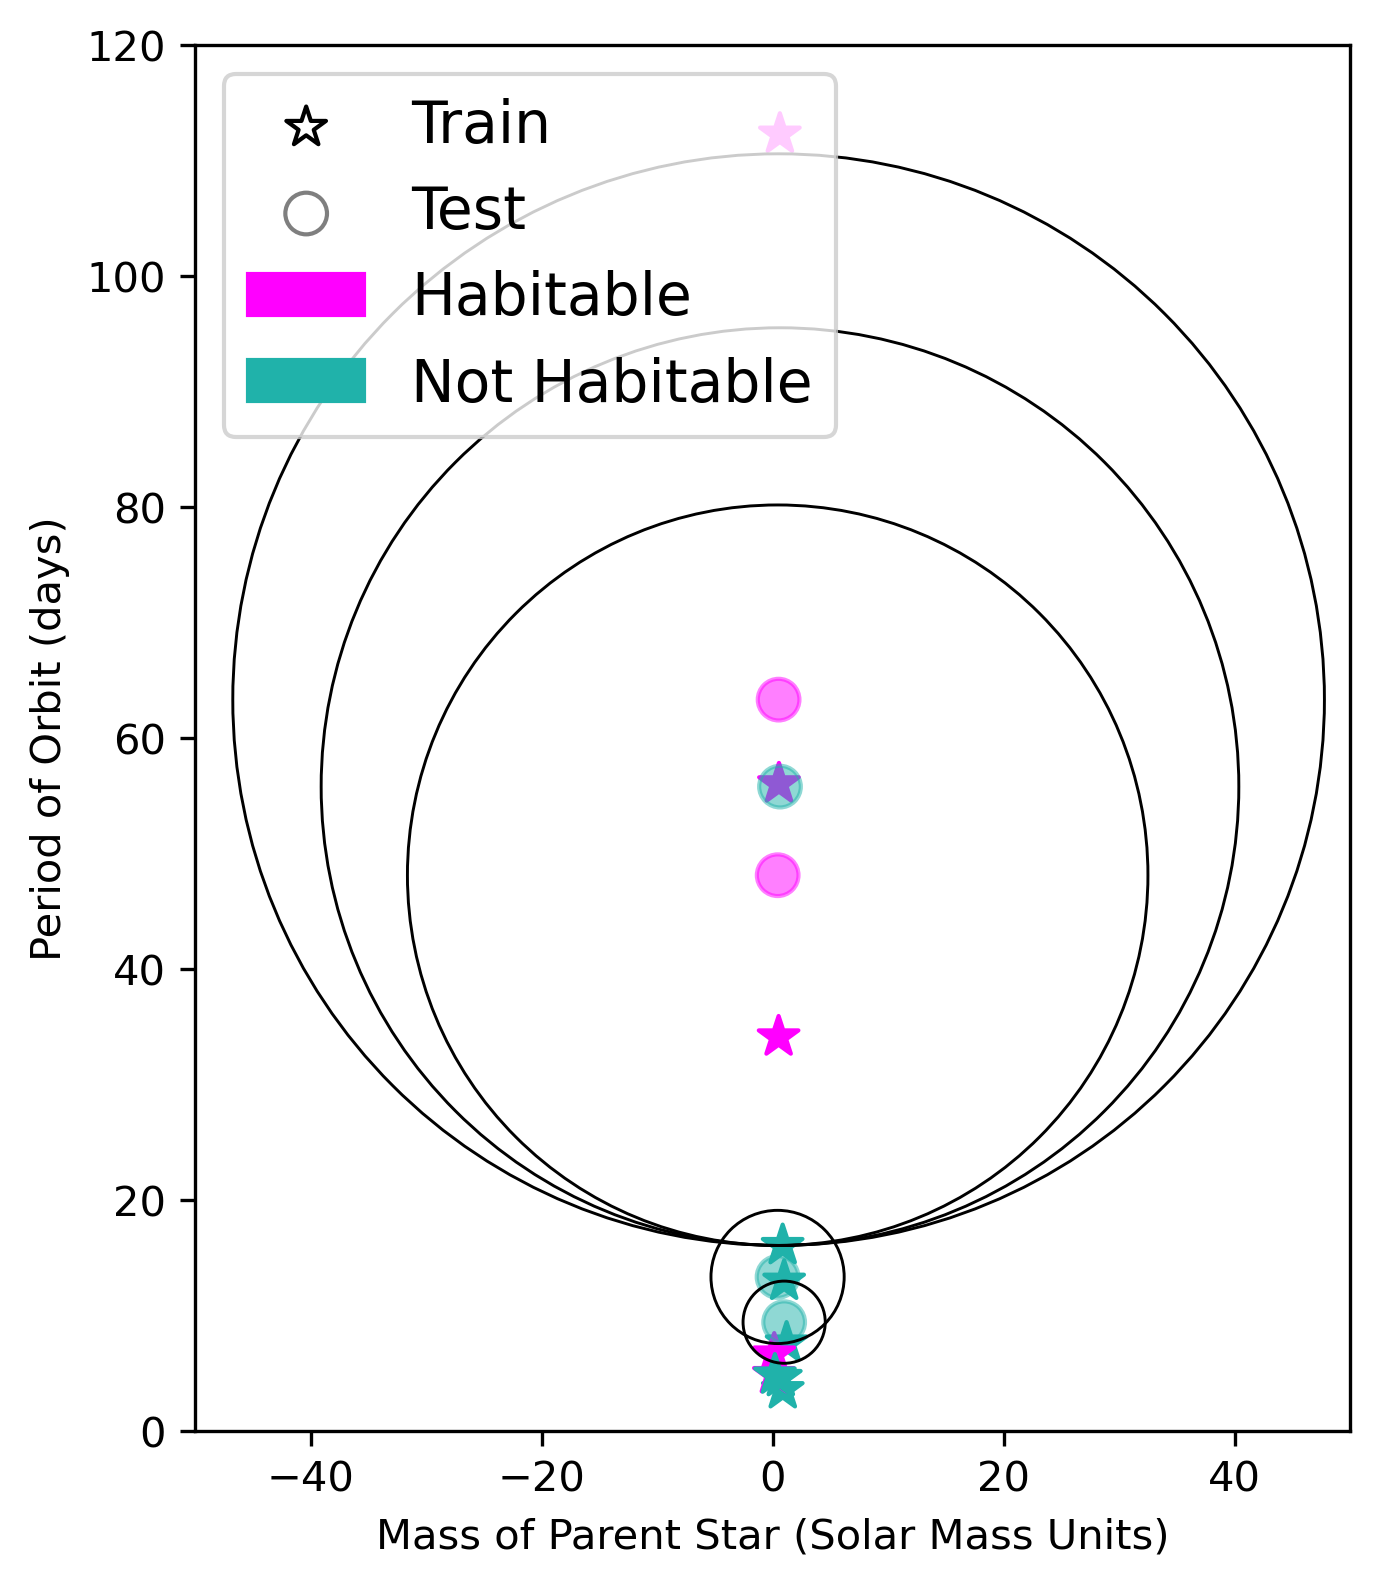

In [166]:
plt.figure(figsize=(10,6))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])


a= plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',facecolor = 'None',\
            c = TrainSet['P_HABITABLE'], s = 100, label = 'Train', cmap=cmap) 

#a.set_facecolor('none')


a= plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',facecolor = 'None',\
            c = TestSet['P_HABITABLE'], s = 100, label = 'Test', cmap=cmap, alpha=0.5) 

#a.set_facecolor('none')

for i in range(len(TestSet)): #plot neighbors

    circle1=plt.Circle((TestSet['S_MASS'].iloc[i],TestSet['P_PERIOD'].iloc[i]),model.kneighbors(Xtest.iloc[:,:2])[0][i,2],\
                       lw = 0.7, edgecolor='k',facecolor='none')
    plt.gca().add_artist(circle1)
    
plt.gca().set_aspect(1)

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()
leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[0].set_facecolor('none')
leg.legend_handles[1].set_color('k')
leg.legend_handles[1].set_facecolor('none')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14)

plt.xlim(-50,50)
plt.ylim(0,120)
plt.xlabel('Mass of Parent Star (Solar Mass Units)')
plt.ylabel('Period of Orbit (days)');

#plt.savefig('HabPlanetsKNN2features.png', dpi = 300)

### Nota algo particular en el gráfico?

Lo más destacable del gráfico es que los datos no están escalados, lo que afecta directamente al cálculo de distancias del algoritmo KNN. Esto provoca que el período orbital, cuyos valores son mucho mayores que los de la masa estelar, domine casi por completo la clasificación. Como consecuencia, los datos aparecen comprimidos en el eje de masa y los círculos de vecindad alcanzan valores de masa físicamente absurdos. Por ello, es necesario normalizar para que exista una mejor visualizacion y armado del algoritmo.

 **Si una dimensión tiene un rango mucho mayor que las otras, dominará el proceso de decisión. Este problema se puede solucionar mediante el <b>escalado</b>. El escalado es un paso de preprocesamiento muy importante para la mayoría de los algoritmos de aprendizaje automático.**



Algunos ejemplos de algoritmos de Scaler [aquí](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html).

Usaremos [`RobustScaler()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html), que se comporta mejor con outliers que la versión estándar, ya que escala de acuerdo a percentiles. Específicamente, usa la mediana (percentil 50) y el rango intercuartílico (IQR = Q3 - Q1), lo cual lo hace menos sensible a valores extremos


In [167]:
scaler = sklearn.preprocessing.RobustScaler() #inicializamos el Scaler

#### Importante!!

Debemos ajustar el escalador **sólo con los datos de entrenamiento**. Esto se hace porque **el modelo no debe tener acceso a los datos de prueba durante el entrenamiento**. Si usamos los datos de prueba para ajustar el escalador, estaríamos filtrando información del futuro, lo que se conoce como data leakage.

Esto puede llevar a dos problemas: por un lado, el modelo podría parecer más preciso de lo que realmente es, y por otro, podría aprender patrones que no se generalizan bien a datos nuevos, lo que se traduce en sobreajuste.

Para evitar esto, primero se ajusta el escalador con los datos de entrenamiento (`fit`), y luego se usa ese mismo escalador para transformar tanto el entrenamiento como el test (`transform`).

In [168]:
scaler.fit(Xtrain) # importante: solo escalamos el set de entrenamiento

RobustScaler()

In [169]:
scaledXTrain = scaler.transform(Xtrain)
scaledXtest = scaler.transform(Xtest)

In [170]:
scaledXTrain,scaledXtest

(array([[ 0.47222222, -0.18360363, -0.33840183],
        [ 0.44444444,  0.06038761,  0.05671512],
        [ 1.38888889, -0.10467304, -0.14339694],
        [-0.22222222,  1.94175736,  1.60417741],
        [ 0.80555556,  0.        ,  0.        ],
        [-1.66666667, -0.15801948, -0.43679409],
        [ 0.        , -0.16299717, -0.31519247],
        [-1.58333333, -0.12323674, -0.38472405],
        [ 1.19444444, 21.311672  , 11.01745224],
        [ 0.33333333,  3.04655169,  2.38937206],
        [-0.52777778,  0.41352236,  0.3761471 ],
        [-0.44444444,  0.84198052,  0.66159817],
        [-1.41666667, -0.15877753, -0.40201197]]),
 array([[-0.19444444,  0.8370915 ,  0.81076169],
        [-0.77777778,  0.00703724, -0.10517751],
        [-0.52777778,  0.98432221,  0.85796876],
        [ 0.80555556, -0.06956397, -0.10258941],
        [-0.75      ,  0.68709948,  0.46718637]]))

In [171]:
scaler.inverse_transform #esto invierte el escalado si es necesario

<bound method RobustScaler.inverse_transform of RobustScaler()>

**Ahora, con los datos escalados, aplique el modelo de kNN inicializado anteriormente, genere las predicciones y genere la misma visualización que en el caso anterior**

In [172]:
model.fit(scaledXTrain[:, :2], ytrain)
ypred_scaled = model.predict(scaledXtest[:, :2])
print("Accuracy Test (Escalado)", metrics.accuracy_score(ytest, ypred_scaled))

Accuracy Test (Escalado) 0.8


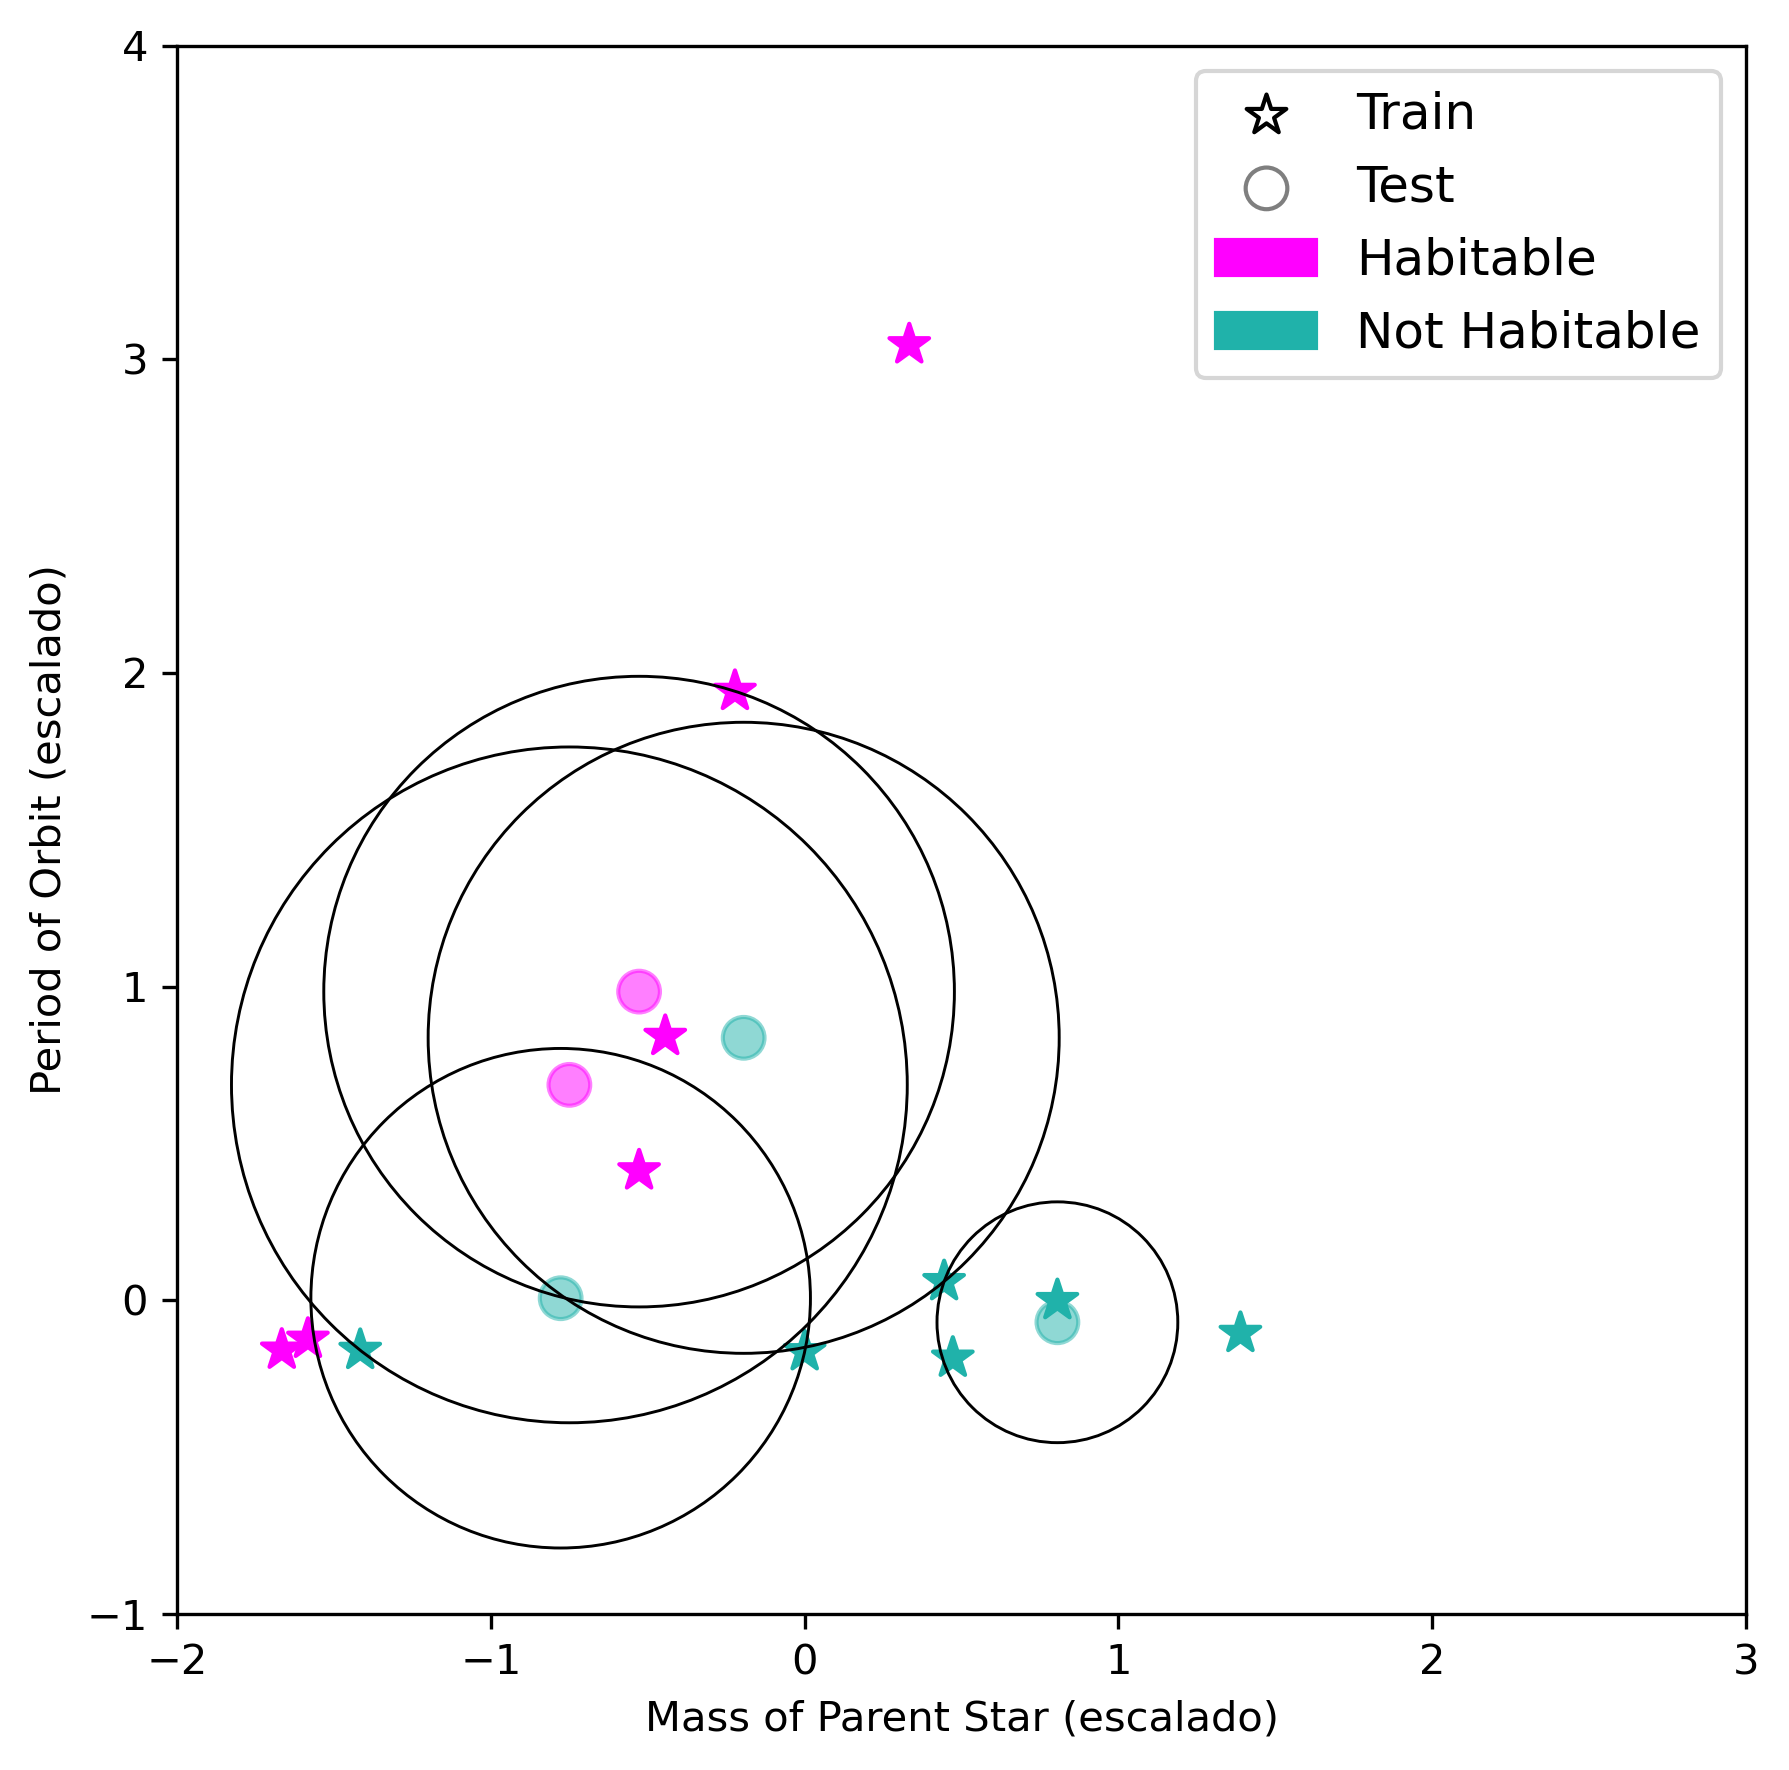

In [178]:
plt.figure(figsize=(10,6))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

a = plt.scatter(scaledXTrain[:,0], scaledXTrain[:,1], marker='*', facecolor='None',
                c=ytrain, s=100, label='Train', cmap=cmap)

a = plt.scatter(scaledXtest[:,0], scaledXtest[:,1], marker='o', facecolor='None',
                c=ytest, s=100, label='Test', cmap=cmap, alpha=0.5)

distances, indices = model.kneighbors(scaledXtest[:,:2])

for i in range(len(scaledXtest)):
    circle1 = plt.Circle((scaledXtest[i,0], scaledXtest[i,1]), distances[i,2],
                          lw=0.7, edgecolor='k', facecolor='none')
    plt.gca().add_artist(circle1)

plt.gca().set_aspect(1)

plt.xlim(-2, 3)
plt.ylim(-1, 4)

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

ax = plt.gca()
plt.legend()
leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[0].set_facecolor('none')
leg.legend_handles[1].set_color('k')
leg.legend_handles[1].set_facecolor('none')

plt.legend(handles=[leg.legend_handles[0], leg.legend_handles[1], magentapatch, bluepatch],
           loc='upper right', fontsize=12)

plt.xlabel('Mass of Parent Star (escalado)')
plt.ylabel('Period of Orbit (escalado)')
plt.tight_layout()

**Repita el proceso de kNN escalado, pero usando todas las caracteristicas, y compare el accuracy**

In [179]:
fullmodel = neighbors.KNeighborsClassifier(n_neighbors=3)
fullmodel.fit(scaledXTrain, ytrain)

KNeighborsClassifier(n_neighbors=3)

In [180]:
acc_train_full = metrics.accuracy_score(ytrain, fullmodel.predict(scaledXTrain))
acc_test_full = metrics.accuracy_score(ytest, fullmodel.predict(scaledXtest))

In [181]:
print("Accuracy Train (todas las features, escalado):", acc_train_full)
print("Accuracy Test (todas las features, escalado):", acc_test_full)

Accuracy Train (todas las features, escalado): 0.8461538461538461
Accuracy Test (todas las features, escalado): 0.8


### Preguntas 

- Descubrimos que kNN necesita escalado ¿DT tiene el mismo problema?

El árbol solo mira una variable a la vez para hacer el corte, así que no importa en qué escala esté. kNN, en cambio, mide distancias combinando todas las variables juntas, así que la que tenga números más grandes termina dominando el cálculo. Por eso kNN sí necesita escalado y DT no.

- Compare las fortalezas y debilidades de DT y kNN

Las fortalezas que tiene un DT son que su visualización es fácil de entender y no necesita de un escalado. Por otra parte su debilidad es que este modelo es muy propenso a realizar overfitting con pocos datos. 

El modelo kNN tiene como fortalezas el ser capaz de representar relaciones no lineales sin asumir una distribucion de los datos. Mientras que sus debilidades son su sensibilidad ante outliers, la eleccion del parámetro k puede ser muy determinante en los resultados y la necesidad de un escalado casi obligatorio. 

- ¿Qué diferencia conceptual hay entre cómo clasifica un árbol de decisión y cómo clasifica kNN?

El DT clasifica mediante una serie de reglas jerárquicas específicas. Por ejemplo, como se hizo anteriormente, puede preguntar si la masa estelar es menor a $0.83\,M_{\odot}$ y, según la respuesta, seguir distintas ramas hasta llegar a una determinada clasificación.

Para kNN, en cambio, el modelo no aprende reglas ni parámetros, sino que memoriza el conjunto de entrenamiento. Al clasificar un punto nuevo, mide la distancia a los puntos almacenados y asigna la clase según la mayoría de los $k$ vecinos más cercanos.

- ¿Por qué el accuracy en entrenamiento no basta para evaluar un modelo?

El accuracy de entrenamiento solo dice qué tan bien el modelo se ajustó a los datos que ya vio, no dice nada sobre la capacidad de generalizar datos nuevos. Esto se puede ver en el caso de DT el cual tuvo un 100% en entrenamiento pero en test bajo a 60%. 

- ¿Por qué kNN requiere escalamiento y un árbol de decisión no necesariamente?

Porque kNN utiliza una métrica de distancia para determinar qué puntos son los más cercanos, como la euclídea, Minkowski o Manhattan. Por ejemplo para este contexto la distancia euclídea sería 
$$ d = \sqrt{(M_1-M_2)^{2}+(P_1-P_2)^{2}}$$

 Si las variables tiene escalas muy diferentes, una puede terminar dominando en el cálculo de la distancia. El árbol de decisión clasifica mediante umbrales para cada variable por lo que realizar un escalamiento no termina siendo necesario. 

- Si tuvieras que elegir uno de los dos métodos para este dataset pequeño, ¿cuál elegirías y por qué?

Elegiría kNN, ya que es un método sencillo y funciona bien cuando hay pocos datos. Además, permite capturar relaciones no lineales sin necesidad de construir reglas complejas. Solo habría que tener en cuenta el escalamiento de las variables y elegir un $k$ óptimo para obtener buenos resultados.
 
